In [4]:
from typing_extensions import Dict, TypedDict
from langgraph.graph import StateGraph

In [ ]:
class AgentState(TypedDict):
    message: str

def greeting_node(state: AgentState) -> AgentState:
    """A simple node that generates a greeting message."""
    state['message']="Hey " + state['message'] + ",How is your day going?"
    return state





In [13]:
graph=StateGraph(AgentState)

graph.add_node("greet",greeting_node)

graph.set_entry_point("greet")
graph.set_finish_point("greet")

app=graph.compile()


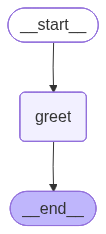

In [10]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
result=app.invoke({"message":"John"})

In [12]:
result["message"]

'HeyJohn,How is your day going?'

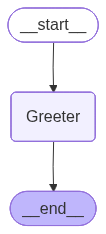

In [17]:
from typing_extensions import Dict, TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    message:str

def node_greeting(state:AgentState)->AgentState:
    """ A simple node that generates a greeting message."""
    state['message']= state['message'] + "You are doing great job learnging Langgraph!"

    return state

graph=StateGraph(AgentState)

graph.add_node("Greeter",node_greeting)

graph.set_entry_point("Greeter")
graph.set_finish_point("Greeter")

new_app=graph.compile()

from IPython.display import Image, display
display(Image(new_app.get_graph().draw_mermaid_png()))


In [19]:
result=new_app.invoke({"message":"Nilofar,"})
result["message"]

'Nilofar,You are doing great job learnging Langgraph!'

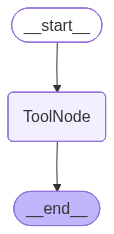

In [26]:
from typing_extensions import Dict, TypedDict
from langgraph.graph import StateGraph

class AgentNode(TypedDict):
    message:str

def node_tool(state:AgentNode)->AgentNode:
    """ Simple node creating a message for tool node"""

    state['message']="Hi " + state["message"] + " You are creating tool node, keep it up!"

    return state

graph=StateGraph(AgentNode)

graph.add_node("ToolNode",node_tool)
graph.set_entry_point("ToolNode")
graph.set_finish_point("ToolNode")

tool_app=graph.compile()

from IPython.display import Image, display
display(Image(tool_app.get_graph().draw_mermaid_png()))


In [27]:
result=tool_app.invoke({"message":"Nilofar"})
result["message"]

'Hi Nilofar You are creating tool node, keep it up!'

In [11]:
from typing_extensions import Dict, TypedDict,List
from langgraph.graph import StateGraph

In [12]:
class AgentState(TypedDict):
    values:List[int]
    name:str
    result:str

In [13]:
def process_values(state:AgentState)->AgentState:
    """ This function handles multiple different inputs"""
    print(state)
    state["result"] = f"Hi there {state["name"]}! your sum = {sum(state["values"])}"
    print(state)
    return state



In [14]:
graph=StateGraph(AgentState)
graph.add_node("Process_Inputs",process_values)
graph.set_entry_point("Process_Inputs")
graph.set_finish_point("Process_Inputs")

app=graph.compile()



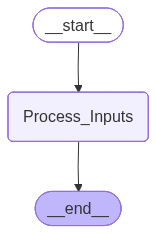

In [15]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))



In [ ]:
app.invoke({"values":[1,2,3,4],"name":"Nilofar"})


{'values': [1, 2, 3, 4], 'name': 'Nilofar'}
{'values': [1, 2, 3, 4], 'name': 'Nilofar', 'result': 'Hi there Nilofar! your sum = 10'}


{'values': [1, 2, 3, 4],
 'name': 'Nilofar',
 'result': 'Hi there Nilofar! your sum = 10'}

In [18]:
answers["result"]

'Hi there Nilofar! your sum = 10'

In [42]:
from typing_extensions import Dict, TypedDict,List
from langgraph.graph import StateGraph

In [43]:
class AgentState(TypedDict):
    values:List[int]
    name:str
    operation:str
    result:int
    output:str

In [44]:
def process_inputs(state:AgentState)->AgentState:
    """AgentState
    This function handles multiple different inputs and performs an operation on the values."""

    if state["operation"]=="+":
        state["result"]=sum(state["values"])
    elif state["operation"]=="*":
        result=1
        for num in state["values"]:
            result*=num
        state["result"]=result
    return state

In [63]:
def process_output(state:AgentState)->AgentState:
    """ This function generates a message based on the result of the operation."""
    print(state)
    state["output"]=f"Hi there {state['name']}! your answer = {state['output']}"
    print(state)
    return state

In [64]:
graph=StateGraph(AgentState)
graph.add_node("ProcessValues", process_inputs)
graph.set_entry_point("ProcessValues")
graph.add_node("ProcessOutput", process_output)
graph.set_finish_point("ProcessOutput")

app1=graph.compile()

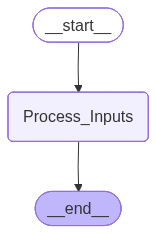

In [65]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [68]:
result=app1.invoke({"values":[1,2,3,4],"name":"Nilofar","operation":"*"})
print(result)


{'values': [1, 2, 3, 4], 'name': 'Nilofar', 'operation': '*', 'result': 24}


# generate 3rd graph

In [75]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    name:str
    age:str
    final:str
def first_node(state:AgentState)->AgentState:
    state["final"]=f"Hi {state["name"]}"
    return state

def second_node(state:AgentState)->AgentState:
    """ This is second node for message generation"""

    state["final"]=state["final"]+f" you are {state['age']} years old"
    return state


In [76]:
graph=StateGraph(AgentState)
graph.add_node("first_node",first_node)
graph.add_node("second_node",second_node)
graph.set_entry_point("first_node")
graph.add_edge("first_node","second_node")
graph.set_finish_point("second_node")

new_app=graph.compile()

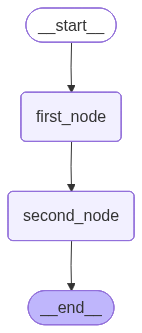

In [77]:
from IPython.display import Image, display
display(Image(new_app.get_graph().draw_mermaid_png()))

In [78]:
result=new_app.invoke({"name":"Afrah","age":"12"})
result["final"]

'Hi Afrah you are 12 years old'

In [111]:
# Graph adding three nodes and pass the message

from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class new_agent_state(TypedDict):
    name:str
    age:int
    skills:list[str]

def node1(state:new_agent_state)->new_agent_state:
    """This is first node for message generation"""
    state["name"]=f"Hi {state["name"]}" 
    return state

def node2(state:new_agent_state)->new_agent_state:
    """This is second node for message generation"""
    state["age"]=f" you are {state["age"]} years old"
    return state

def node3(state:new_agent_state)->new_agent_state:
    """This is third node for message generation"""
    state["final"]=state["name"] + state["age"] + f"and you have following skills {state["skills"]}"
    return state


In [112]:
new_graph=StateGraph(new_agent_state)
new_graph.add_node("Name_node",node1)
new_graph.add_node("Age_node",node2)
new_graph.add_node("Final_msg_node",node3)
new_graph.set_entry_point("Name_node")
new_graph.add_edge("Name_node","Age_node")
new_graph.add_edge("Age_node","Final_msg_node")

new_app=new_graph.compile()

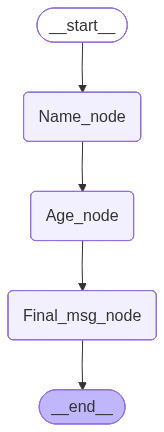

In [113]:
from IPython.display import Image, display
display(Image(new_app.get_graph().draw_mermaid_png()))

In [115]:
result=new_app.invoke({"name":"Nilofar","age":40,"skills":["python","Langraph","AWS"]})
print(result)

{'name': 'Hi Nilofar', 'age': ' you are 40 years old', 'skills': ['python', 'Langraph', 'AWS']}


# adding conditonal node

In [128]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
    n1:int
    operation:str
    n2:int
    out_put:int

def adder(state:AgentState)->AgentState:
    """This is addition operation node"""
    state["out_put"]=state["n1"]+state["n2"]
    return state

def subtractor(state:AgentState)->AgentState:
    """This is subtraction operation node"""
    state["out_put"]=state["n1"]-state["n2"]
    return state

def decide_next_node(state:AgentState)->AgentState:
    """ This node decides the operation to perform"""

    if state["operation"]=="+":
        return "addition_operation"
    elif state["operation"]=="-":
        return "subtraction_operation"
    
    

In [129]:
output_graph=StateGraph(AgentState)

output_graph.add_node("addition_node",adder)
output_graph.add_node("subtract_node",subtractor)
output_graph.add_node("router",lambda state:state)
output_graph.add_edge(START,"router")
output_graph.add_conditional_edges(
    "router",
    decide_next_node,
    { "addition_operation":"addition_node",
     "subtraction_operation":"subtract_node"}

)
output_graph.add_edge("addition_node",END)
output_graph.add_edge("subtract_node",END)

In [130]:
App=output_graph.compile()

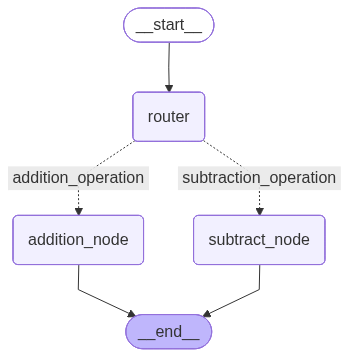

In [131]:
from IPython.display import Image, display
display(Image(App.get_graph().draw_mermaid_png()))

In [132]:
final_output=AgentState(n1=10,operation="-",n2=5)


In [133]:
print(App.invoke(final_output))

{'n1': 10, 'operation': '-', 'n2': 5, 'out_put': 5}


# Example of adding conditional nodes with edges

In [172]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END

class AgentState(TypedDict):
    N1:int
    N2:int
    N3:int
    N4:int
    operator:str
    operator2:str
    output1:int
    output2:int

def adder1(state:AgentState)->AgentState:
    """ This node performs first addition operation"""
    state["output1"]=state["N1"]+state["N2"]
    return state
def subtractor1(state:AgentState)->AgentState:
    """This node performs first subtraction operation"""
    state["output1"]=state["N1"]-state["N2"]
    return state
def adder2(state:AgentState)->AgentState:
    """ This node performs second addition operation"""
    state["output2"]=state["N3"]+state["N4"]
    return state    
def subtractor2(state:AgentState)->AgentState:
    """ This node performs second subtraction operation"""
    state["output2"]=state["N3"]-state["N4"]
    return state

def decision_node1(state:AgentState)->AgentState:
    """ This node decides the first operation to perform"""
    if state["operator"]=="+":
        return "addition_operation1"
    elif state["operator"]=="-":
        return "subtraction_operation1"
    
def decision_node2(state:AgentState)->AgentState:
    """This node decides the second operation to perform"""
    if state["operator2"]=="+":
        return "addition_operation2"
    elif state["operator2"]=="-":
        return "subtraction_operation2"

In [177]:
decision_graph=StateGraph(AgentState)

decision_graph.add_node("addition_node1",adder1)
decision_graph.add_node("subtraction_node1",subtractor1)
decision_graph.add_node("addition_node2",adder2)
decision_graph.add_node("subtraction_node2",subtractor2)

decision_graph.add_node("Router1",lambda state:state)
decision_graph.add_edge(START,"Router1")
decision_graph.add_conditional_edges(
    "Router1", 
    decision_node1,
    {
        "addition_operation1":"addition_node1",
        "subtraction_operation1":"subtraction_node1"
    }
    
)

decision_graph.add_node("Router2",lambda state:state)

decision_graph.add_edge("addition_node1","Router2")
decision_graph.add_edge("subtraction_node1","Router2")
decision_graph.add_conditional_edges(
    "Router2",
    decision_node2,
    {
        "addition_operation2":"addition_node2",
        "subtraction_operation2":"subtraction_node2"
    }
)
decision_graph.add_edge("addition_node2",END)
decision_graph.add_edge("subtraction_node2",END)



In [178]:
Final_App=decision_graph.compile()

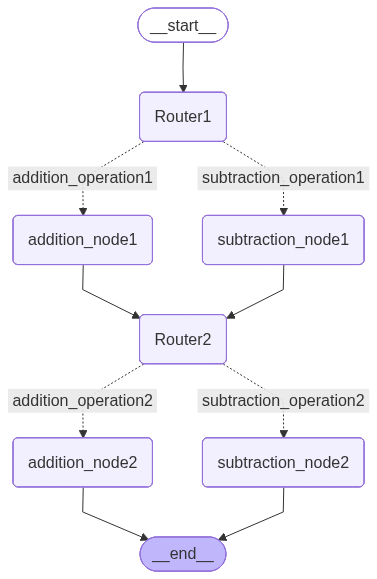

In [179]:
from IPython.display import Image, display
display(Image(Final_App.get_graph().draw_mermaid_png()))

In [186]:
initial_state = {
    "N1": 10,
    "N2": 5,
    "N3": 7,
    "N4": 2,
    "operator": "-",
    "operator2": "+"
}

In [187]:
result = Final_App.invoke(initial_state)

print(result)

{'N1': 10, 'N2': 5, 'N3': 7, 'N4': 2, 'operator': '-', 'operator2': '+', 'output1': 5, 'output2': 9}


# Loop in Graph

In [189]:
from langgraph.graph import StateGraph, END
import random
from typing_extensions import TypedDict,Dict,List

class AgentState(TypedDict):
    name:str
    number:List[int]
    counter:int

def greeter_node(state:AgentState)->AgentState:
    """A simple node that generates a greeting message."""
    state['name']= f"Hi there, {state["name"]}"
    state["counter"]=0
    return state

def random_node(state:AgentState)->AgentState:
    """ This node generates a random number and appends it to the list of numbers in the state."""
    random_number=random.randint(1,10)
    state["number"].append(random_number)
    state["counter"]+=1
    return state

def should_continue(state:AgentState)->AgentState:
    """Thsi function to decide what to do next"""
    if state["counter"]<5:
        print("ENTERING LOOP",state["counter"])
        return "loop"
    else:   
        return "exit"
    
graph=StateGraph(AgentState)
graph.add_node("Greeter",greeter_node)
graph.add_node("Random",random_node)

graph.add_edge("Greeter","Random")

graph.add_conditional_edges(

    "Random",
    should_continue,
    {
        "loop":"Random",
        "exit":END
    }
)

graph.set_entry_point("Greeter")

app = graph.compile()

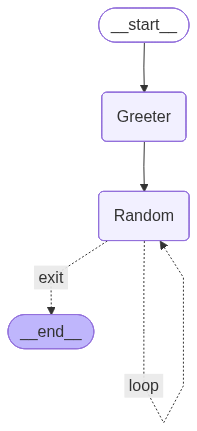

In [190]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [191]:
app.invoke({"name":"Nilofar","number":[],"counter":-1})

ENTERING LOOP 1
ENTERING LOOP 2
ENTERING LOOP 3
ENTERING LOOP 4


{'name': 'Hi there, Nilofar', 'number': [1, 9, 1, 5, 3], 'counter': 5}